In [36]:
import os
from pathlib import Path
import requests
import zipfile
import geopandas as gpd
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geo_root = repo_root.parent.parent / 'Data' / 'Geospatial'

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')
16 voivodeships (should be 16)


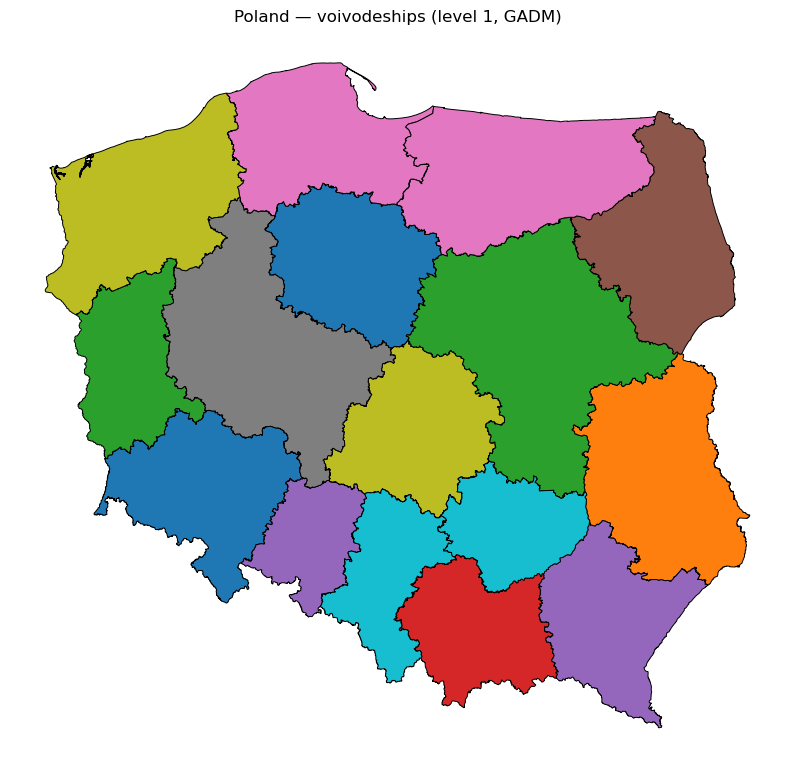

In [37]:
# 1) download GADM (example host: UC Davis geodata mirror)
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_POL_shp.zip"
zip_path = geo_root / "gadm41_POL_shp.zip"
if not os.path.exists(zip_path):
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

# 2) unzip (optional) and read level-1 shapefile
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(geo_root / "gadm41_POL_shp")

# shapefile for admin level 1 inside the zip is typically named like: gadm41_POL_1.shp
gdf = gpd.read_file(geo_root / "gadm41_POL_shp/gadm41_POL_1.shp")  # level 1 = voivodeships

# quick inspect
print(gdf.columns)
print(len(gdf), "voivodeships (should be 16)")

# 3) plot
ax = gdf.plot(edgecolor="black", linewidth=0.7, figsize=(10,10), column="NAME_1", legend=False)
ax.set_title("Poland — voivodeships (level 1, GADM)")
ax.axis("off")
plt.show()


In [ ]:
# =============================================================================
# STEP 1: Load SVG and Extract Raw Paths
# =============================================================================
# This cell loads the 1975 voivodeship boundaries from an SVG file
# Note: SVG paths may have gaps/holes that we'll fix using GADM boundary

import xml.etree.ElementTree as ET
import re
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.ops import unary_union
from shapely import affinity
import numpy as np

input_svg = repo_root / "POL_Voivodships_1975.svg"

print(f"Loading SVG from: {input_svg}")
print(f"SVG file exists: {input_svg.exists()}")

def parse_svg_path(path_data):
    """
    Parse SVG path data (M, L, C, H, V, Z commands) into coordinates.
    Returns list of coordinate tuples.
    """
    coords = []
    tokens = re.findall(r'[MLCZHVmlczhv]|[-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?', path_data)
    
    i = 0
    current_x, current_y = 0, 0
    start_x, start_y = 0, 0
    
    while i < len(tokens):
        cmd = tokens[i]
        
        try:
            if cmd.upper() == 'M':  # Move to
                if i + 2 < len(tokens):
                    current_x = float(tokens[i+1])
                    current_y = float(tokens[i+2])
                    start_x, start_y = current_x, current_y
                    coords.append((current_x, current_y))
                    i += 3
                else:
                    i += 1
                    
            elif cmd.upper() == 'L':  # Line to
                if i + 2 < len(tokens):
                    current_x = float(tokens[i+1])
                    current_y = float(tokens[i+2])
                    coords.append((current_x, current_y))
                    i += 3
                else:
                    i += 1
                    
            elif cmd.upper() == 'H':  # Horizontal line
                if i + 1 < len(tokens):
                    current_x = float(tokens[i+1])
                    coords.append((current_x, current_y))
                    i += 2
                else:
                    i += 1
                    
            elif cmd.upper() == 'V':  # Vertical line
                if i + 1 < len(tokens):
                    current_y = float(tokens[i+1])
                    coords.append((current_x, current_y))
                    i += 2
                else:
                    i += 1
                    
            elif cmd.upper() == 'C':  # Cubic Bezier (use end point only)
                if i + 6 < len(tokens):
                    current_x = float(tokens[i+5])
                    current_y = float(tokens[i+6])
                    coords.append((current_x, current_y))
                    i += 7
                else:
                    i += 1
                    
            elif cmd.upper() == 'Z':  # Close path
                if coords and coords[-1] != (start_x, start_y):
                    coords.append((start_x, start_y))
                i += 1
            else:
                # Try as implicit coordinate
                try:
                    current_x = float(cmd)
                    if i + 1 < len(tokens):
                        current_y = float(tokens[i+1])
                        coords.append((current_x, current_y))
                        i += 2
                    else:
                        i += 1
                except ValueError:
                    i += 1
        except (ValueError, IndexError):
            i += 1
    
    return coords

# Parse the SVG file
tree = ET.parse(input_svg)
root = tree.getroot()
ns = {'svg': 'http://www.w3.org/2000/svg'}

# Extract all path elements
raw_paths = {}
for path in root.findall('.//svg:path', ns):
    path_id = path.get('id')
    path_data = path.get('d')
    if path_id and path_data:
        coords = parse_svg_path(path_data)
        if len(coords) >= 3:
            raw_paths[path_id] = coords

print(f"\n✓ Extracted {len(raw_paths)} paths from SVG")
print(f"  Path names: {list(raw_paths.keys())}")

Loading SVG from: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/new_map.svg
SVG file exists: True

✓ Extracted 0 paths from SVG
  Path names: []


In [39]:
# =============================================================================
# STEP 2: Create Initial Polygons and Apply Coordinate Transform
# =============================================================================
# The SVG uses a coordinate system with Y-axis pointing down
# We need to flip it and scale to match geographic coordinates

# Create initial polygons from raw paths
initial_polygons = {}
failed_paths = []

for name, coords in raw_paths.items():
    try:
        poly = Polygon(coords)
        if not poly.is_valid:
            poly = poly.buffer(0)  # Fix self-intersections
        if poly.is_valid and not poly.is_empty:
            # Handle MultiPolygon - take largest part
            if poly.geom_type == 'MultiPolygon':
                poly = max(poly.geoms, key=lambda p: p.area)
            initial_polygons[name] = poly
        else:
            failed_paths.append((name, "Invalid geometry"))
    except Exception as e:
        failed_paths.append((name, str(e)))

print(f"✓ Created {len(initial_polygons)} valid polygons")
if failed_paths:
    print(f"⚠ Failed: {failed_paths}")

# Create GeoDataFrame with SVG coordinates
gdf_svg = gpd.GeoDataFrame({
    'name': list(initial_polygons.keys()),
    'geometry': list(initial_polygons.values())
})

# Flip Y-axis (SVG has Y pointing down, geography has Y pointing up)
bounds = gdf_svg.total_bounds
center_y = (bounds[1] + bounds[3]) / 2
gdf_svg['geometry'] = gdf_svg['geometry'].apply(
    lambda g: affinity.scale(g, xfact=1, yfact=-1, origin=(0, center_y))
)

print(f"\n✓ Flipped Y-axis for conventional orientation")
print(f"  SVG bounds: {gdf_svg.total_bounds}")

✓ Created 0 valid polygons

✓ Flipped Y-axis for conventional orientation
  SVG bounds: [nan nan nan nan]


In [40]:
# =============================================================================
# STEP 3: Load GADM Poland Boundary (Authoritative Outer Border)
# =============================================================================
# We use GADM level-0 (country boundary) as the definitive Poland outline

gadm_path = geo_root / "gadm41_POL_shp" / "gadm41_POL_0.shp"
gdf_poland = gpd.read_file(gadm_path)
poland_boundary = gdf_poland.geometry.iloc[0]

# Convert to a projected CRS for accurate area calculations
gdf_poland_proj = gdf_poland.to_crs('EPSG:2180')
poland_boundary_proj = gdf_poland_proj.geometry.iloc[0]

print(f"✓ Loaded GADM Poland boundary")
print(f"  GADM CRS: {gdf_poland.crs}")
print(f"  Poland area (EPSG:2180): {poland_boundary_proj.area / 1e6:,.0f} km²")
print(f"  Expected: ~312,685 km²")

✓ Loaded GADM Poland boundary
  GADM CRS: EPSG:4326
  Poland area (EPSG:2180): 312,196 km²
  Expected: ~312,685 km²


In [41]:
# =============================================================================
# STEP 4: Transform SVG Coordinates to Match GADM (Affine Transformation)
# =============================================================================
# We need to find the affine transformation that maps SVG coordinates to EPSG:4326
# Using the outer boundary of SVG voivodeships vs GADM Poland boundary

from scipy.optimize import minimize

# Get SVG union boundary
svg_union = unary_union(gdf_svg.geometry)
svg_bounds = svg_union.bounds  # (minx, miny, maxx, maxy)

# Get GADM bounds in WGS84
gadm_bounds = poland_boundary.bounds

print("SVG bounds:", svg_bounds)
print("GADM bounds (WGS84):", gadm_bounds)

# Calculate simple affine transformation parameters
# SVG to WGS84: x_geo = a*x_svg + b, y_geo = c*y_svg + d
svg_width = svg_bounds[2] - svg_bounds[0]
svg_height = svg_bounds[3] - svg_bounds[1]
gadm_width = gadm_bounds[2] - gadm_bounds[0]
gadm_height = gadm_bounds[3] - gadm_bounds[1]

scale_x = gadm_width / svg_width
scale_y = gadm_height / svg_height

# Use average scale to maintain aspect ratio
scale = (scale_x + scale_y) / 2

# Calculate translation (map SVG center to GADM center)
svg_center_x = (svg_bounds[0] + svg_bounds[2]) / 2
svg_center_y = (svg_bounds[1] + svg_bounds[3]) / 2
gadm_center_x = (gadm_bounds[0] + gadm_bounds[2]) / 2
gadm_center_y = (gadm_bounds[1] + gadm_bounds[3]) / 2

print(f"\nTransformation parameters:")
print(f"  Scale: {scale:.8f}")
print(f"  SVG center: ({svg_center_x:.1f}, {svg_center_y:.1f})")
print(f"  GADM center: ({gadm_center_x:.4f}, {gadm_center_y:.4f})")

SVG bounds: (nan, nan, nan, nan)
GADM bounds (WGS84): (14.12288475000014, 49.002044678000175, 24.145782471000075, 54.83641815200008)

Transformation parameters:
  Scale: nan
  SVG center: (nan, nan)
  GADM center: (19.1343, 51.9192)


SVG bounds: [7.79361320e-01 3.19999799e-07 3.23847290e+03 2.95218070e+03]
GADM bounds: (14.12288475000014, 49.002044678000175, 24.145782471000075, 54.83641815200008)


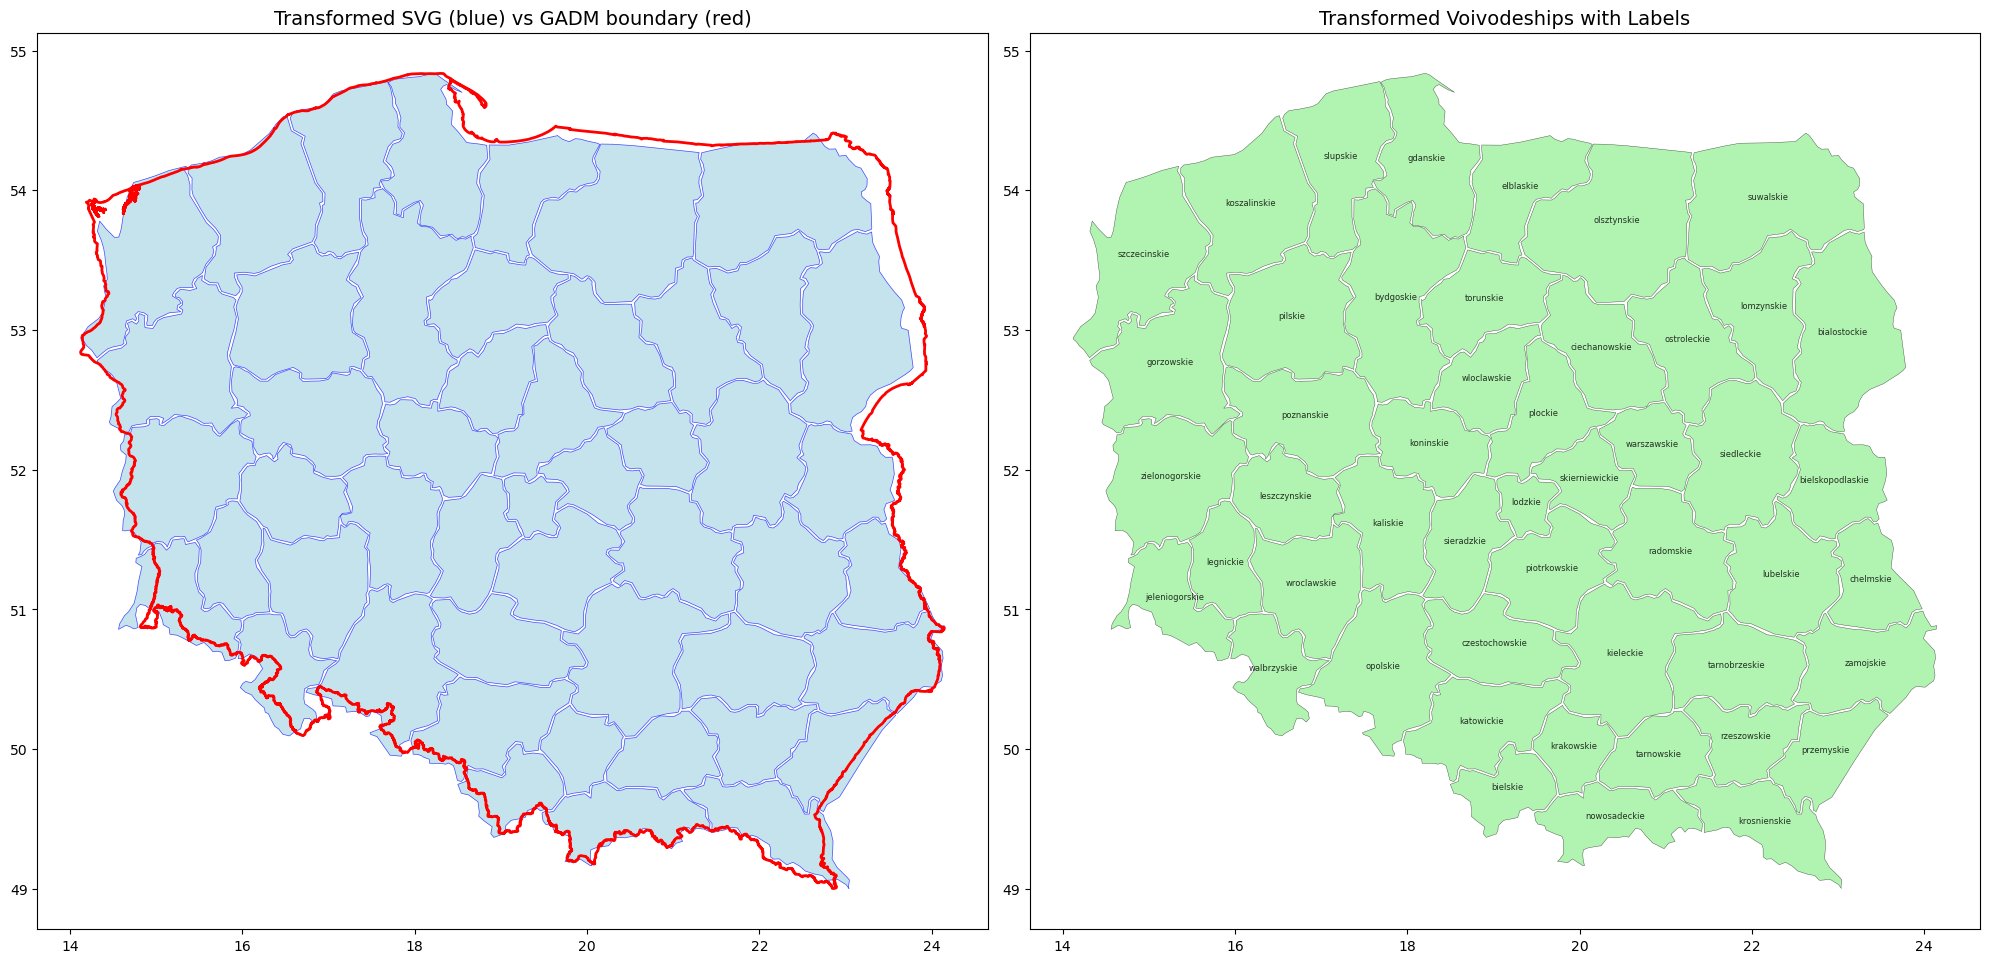


✓ Transformed 49 voivodeships to WGS84
  New bounds: [14.12288475 49.00204468 24.14578247 54.83641815]


In [8]:
# =============================================================================
# STEP 5: Apply Transformation and Create Georeferenced Voivodeships
# =============================================================================
# The transformation needs to:
# 1. Scale SVG to match geographic extent
# 2. Translate to correct position

def transform_geometry(geom, svg_bounds, gadm_bounds):
    """Transform geometry from SVG coordinates to WGS84 using bounds matching"""
    svg_minx, svg_miny, svg_maxx, svg_maxy = svg_bounds
    gadm_minx, gadm_miny, gadm_maxx, gadm_maxy = gadm_bounds
    
    svg_width = svg_maxx - svg_minx
    svg_height = svg_maxy - svg_miny
    gadm_width = gadm_maxx - gadm_minx
    gadm_height = gadm_maxy - gadm_miny
    
    scale_x = gadm_width / svg_width
    scale_y = gadm_height / svg_height
    
    # Transform: x_new = (x_old - svg_minx) * scale_x + gadm_minx
    #            y_new = (y_old - svg_miny) * scale_y + gadm_miny
    from shapely import affinity
    
    # First translate to origin, then scale, then translate to GADM position
    geom = affinity.translate(geom, xoff=-svg_minx, yoff=-svg_miny)
    geom = affinity.scale(geom, xfact=scale_x, yfact=scale_y, origin=(0, 0))
    geom = affinity.translate(geom, xoff=gadm_minx, yoff=gadm_miny)
    
    return geom

# Get bounds
svg_bounds = gdf_svg.total_bounds  # Already flipped Y
gadm_bounds = poland_boundary.bounds

print(f"SVG bounds: {svg_bounds}")
print(f"GADM bounds: {gadm_bounds}")

# Apply transformation to all voivodeships
gdf_transformed = gdf_svg.copy()
gdf_transformed['geometry'] = gdf_transformed['geometry'].apply(
    lambda g: transform_geometry(g, svg_bounds, gadm_bounds)
)
gdf_transformed.set_crs('EPSG:4326', inplace=True)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Left: Transformed SVG voivodeships vs GADM
gdf_transformed.plot(ax=ax1, edgecolor='blue', facecolor='lightblue', linewidth=0.5, alpha=0.7)
gpd.GeoDataFrame(geometry=[poland_boundary], crs='EPSG:4326').plot(
    ax=ax1, edgecolor='red', facecolor='none', linewidth=2
)
ax1.set_title('Transformed SVG (blue) vs GADM boundary (red)', fontsize=14)

# Right: Overlap visualization
gdf_transformed.plot(ax=ax2, edgecolor='black', facecolor='lightgreen', linewidth=0.3, alpha=0.7)
for idx, row in gdf_transformed.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(row['name'], xy=(centroid.x, centroid.y), ha='center', fontsize=6, alpha=0.8)
ax2.set_title('Transformed Voivodeships with Labels', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\n✓ Transformed {len(gdf_transformed)} voivodeships to WGS84")
print(f"  New bounds: {gdf_transformed.total_bounds}")

Poland area: 312,196 km²
Voivodeships union area: 297,019 km²
Gap area: 21,775 km² (7.0%)


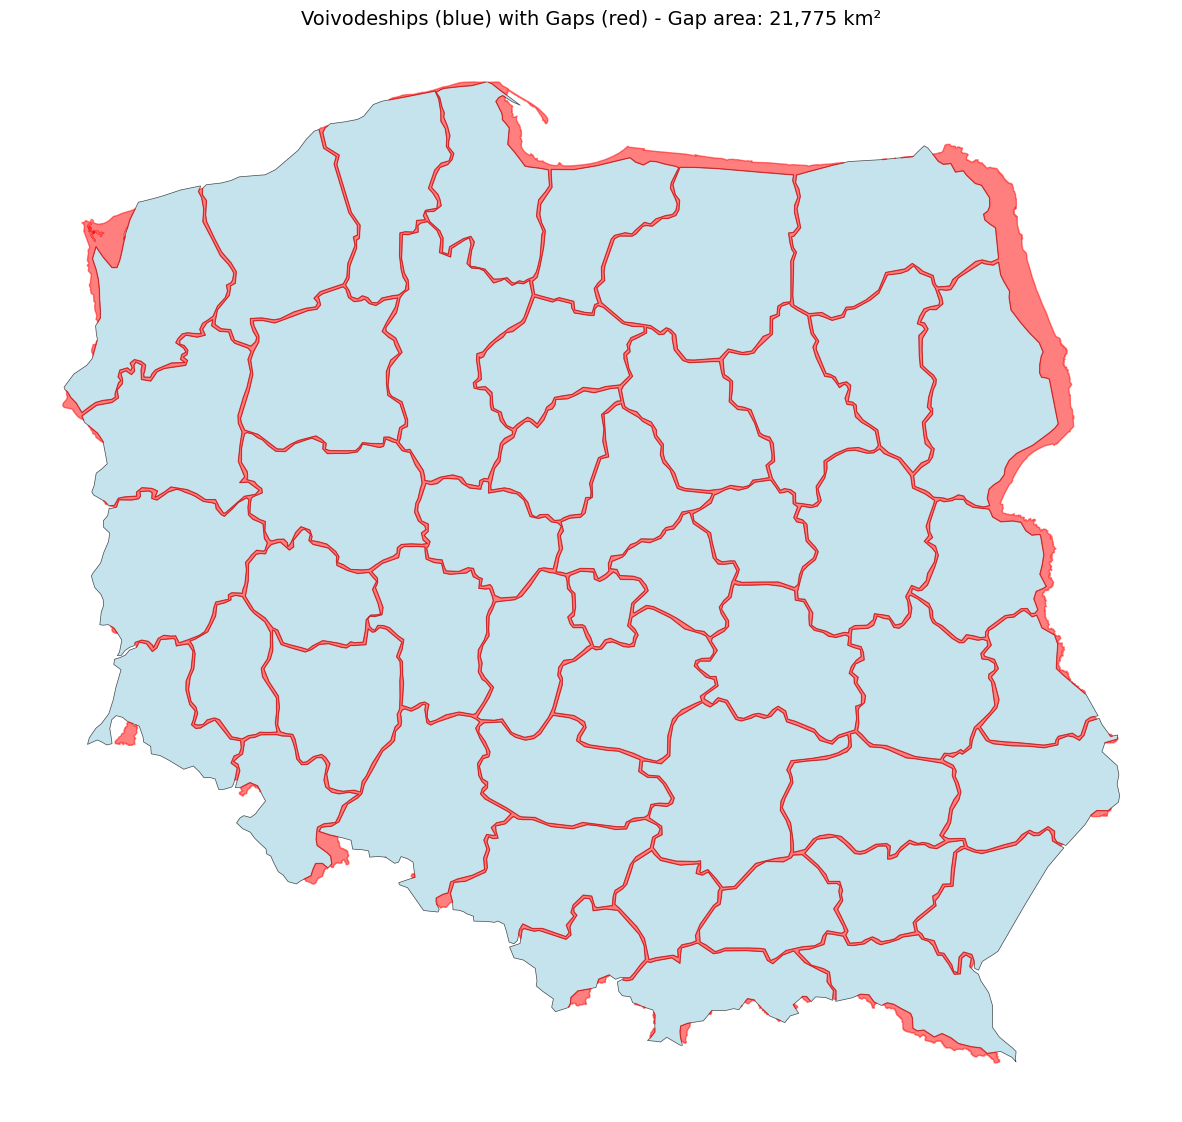

In [14]:
# =============================================================================
# STEP 6: Identify and Analyze Gaps Between Voivodeships
# =============================================================================
# The SVG has empty areas that need to be filled

# Convert to EPSG:2180 for accurate area calculations
gdf_proj = gdf_transformed.to_crs('EPSG:2180')
poland_proj = poland_boundary_proj

# Calculate union of all voivodeships
voiv_union = unary_union(gdf_proj.geometry)

# Find gaps (areas in Poland not covered by any voivodeship)
gaps = poland_proj.difference(voiv_union)

print(f"Poland area: {poland_proj.area / 1e6:,.0f} km²")
print(f"Voivodeships union area: {voiv_union.area / 1e6:,.0f} km²")
print(f"Gap area: {gaps.area / 1e6:,.0f} km² ({100 * gaps.area / poland_proj.area:.1f}%)")

# Visualize gaps
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
gdf_proj.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5, alpha=0.7)
if not gaps.is_empty:
    gpd.GeoDataFrame(geometry=[gaps], crs='EPSG:2180').plot(
        ax=ax, edgecolor='red', facecolor='red', linewidth=1, alpha=0.5
    )
ax.set_title(f'Voivodeships (blue) with Gaps (red) - Gap area: {gaps.area / 1e6:,.0f} km²', fontsize=14)
ax.axis('off')
plt.show()

In [17]:
# =============================================================================
# STEP 7: Fill Gaps Using Point-by-Point Nearest Assignment
# =============================================================================
# For large gaps that span multiple voivodeships, we sample points throughout
# the gap and assign each point to its nearest voivodeship, then merge.

from shapely.geometry import box
from shapely.strtree import STRtree

def fill_gaps_pointwise(gdf, gaps, resolution=2000):
    """
    Fill gaps by sampling points and assigning each to nearest voivodeship.
    
    Args:
        gdf: GeoDataFrame of voivodeships
        gaps: Geometry of gap areas
        resolution: Grid resolution in meters (default 2000m = 2km)
    """
    if gaps.is_empty:
        return gdf
    
    print(f"Filling gaps with {resolution}m resolution...")
    
    gdf_result = gdf.copy()
    
    # Get bounds of gaps
    minx, miny, maxx, maxy = gaps.bounds
    
    # Create grid cells covering the gap area
    x_points = np.arange(minx, maxx + resolution, resolution)
    y_points = np.arange(miny, maxy + resolution, resolution)
    
    print(f"  Grid: {len(x_points)} x {len(y_points)} = {len(x_points) * len(y_points)} cells")
    
    # Build spatial index for voivodeships
    geoms = list(gdf_result.geometry)
    tree = STRtree(geoms)
    
    # Dictionary to collect gap portions for each voivodeship
    gap_additions = {idx: [] for idx in gdf_result.index}
    
    # Process each grid cell
    cell_count = 0
    for x in x_points:
        for y in y_points:
            # Create cell
            cell = box(x, y, x + resolution, y + resolution)
            
            # Check if cell intersects gap
            cell_in_gap = cell.intersection(gaps)
            if cell_in_gap.is_empty or cell_in_gap.area < 100:  # Skip tiny areas
                continue
            
            cell_count += 1
            
            # Find center of cell portion in gap
            cell_center = cell_in_gap.centroid
            
            # Find nearest voivodeship
            min_dist = float('inf')
            nearest_idx = None
            
            for idx, row in gdf_result.iterrows():
                dist = cell_center.distance(row.geometry)
                if dist < min_dist:
                    min_dist = dist
                    nearest_idx = idx
            
            if nearest_idx is not None:
                gap_additions[nearest_idx].append(cell_in_gap)
    
    print(f"  Processed {cell_count} gap cells")
    
    # Merge gap portions into voivodeships
    additions_count = 0
    for idx, portions in gap_additions.items():
        if portions:
            old_geom = gdf_result.loc[idx, 'geometry']
            new_geom = unary_union([old_geom] + portions)
            gdf_result.loc[idx, 'geometry'] = new_geom
            additions_count += len(portions)
            
    print(f"  Added {additions_count} gap portions to voivodeships")
    
    return gdf_result

# Fill gaps with point-by-point assignment
gdf_filled = fill_gaps_pointwise(gdf_proj, gaps, resolution=1000)  # 1km resolution

# Verify coverage
filled_union = unary_union(gdf_filled.geometry)
remaining_gaps = poland_proj.difference(filled_union)
print(f"\n✓ Gap filling complete")
print(f"  Remaining uncovered: {remaining_gaps.area / 1e6:.1f} km²")

Filling gaps with 1000m resolution...
  Grid: 692 x 643 = 444956 cells
  Processed 33137 gap cells
  Added 33137 gap portions to voivodeships

✓ Gap filling complete
  Remaining uncovered: 0.0 km²


In [18]:
# =============================================================================
# STEP 8: Clip Voivodeships to Poland Boundary & Ensure No Overlaps
# =============================================================================
# Use GADM boundary as the authoritative outer border
# This ensures precise outer boundaries and removes any overseas artifacts

from shapely.validation import make_valid

def clip_and_clean_voivodeships(gdf, poland_boundary):
    """
    Clip all voivodeships to Poland boundary and ensure no overlaps.
    """
    gdf_result = gdf.copy()
    
    # Clip each voivodeship to Poland boundary
    for idx in gdf_result.index:
        geom = gdf_result.loc[idx, 'geometry']
        try:
            clipped = geom.intersection(poland_boundary)
            if not clipped.is_valid:
                clipped = make_valid(clipped)
            # Ensure we get a Polygon, not MultiPolygon
            if clipped.geom_type == 'MultiPolygon':
                # Keep only parts that are significant (> 1 km²)
                significant_parts = [p for p in clipped.geoms if p.area > 1e6]
                if len(significant_parts) == 1:
                    clipped = significant_parts[0]
                elif len(significant_parts) > 1:
                    clipped = unary_union(significant_parts)
            gdf_result.loc[idx, 'geometry'] = clipped
        except Exception as e:
            print(f"Warning: Could not clip {gdf_result.loc[idx, 'name']}: {e}")
    
    return gdf_result

# Clip to Poland boundary
gdf_clipped = clip_and_clean_voivodeships(gdf_filled, poland_proj)

# Calculate and display areas
gdf_clipped['area_km2'] = gdf_clipped.geometry.area / 1e6
print("\nVoivodeship areas after clipping:")
print(gdf_clipped[['name', 'area_km2']].sort_values('area_km2', ascending=False).to_string())

total_area = gdf_clipped['area_km2'].sum()
print(f"\nTotal area: {total_area:,.0f} km² (Poland: ~312,685 km²)")


Voivodeship areas after clipping:
                name      area_km2
7        olsztynskie  12378.202898
8       bialostockie  12099.035102
9          suwalskie  11932.568341
1          bydgoskie  10207.030233
48         kieleckie   9346.932312
0       szczecinskie   8995.121472
16        gorzowskie   8826.142525
15           pilskie   8713.763624
4       koszalinskie   8551.162373
25        siedleckie   8277.946234
36          opolskie   8136.755290
17    zielonogorskie   7831.414719
18        poznanskie   7684.111120
3           gdanskie   7324.040335
29         radomskie   7263.936716
28         lubelskie   7137.079238
5           slupskie   6896.740393
32       wroclawskie   6685.994761
46         zamojskie   6593.215122
30      piotrkowskie   6532.989301
11       ostroleckie   6475.027987
47     tarnobrzeskie   6450.010916
10        lomzynskie   6409.008090
38        katowickie   6400.777547
20          kaliskie   6292.659150
12     ciechanowskie   6290.011948
37    czestochowskie

In [19]:
# =============================================================================
# STEP 9: Validate Against Historical Data
# =============================================================================
# Compare extracted areas with Wikipedia historical data

# Historical voivodeship areas (km²) from Wikipedia
HISTORICAL_AREAS = {
    'bialskopodlaskie': 5348, 'bialostockie': 10055, 'bielskie': 3704,
    'bydgoskie': 10349, 'chelmskie': 3866, 'ciechanowskie': 6362,
    'czestochowskie': 6182, 'elblaskie': 6103, 'gdanskie': 7394,
    'gorzowskie': 8484, 'jeleniogorskie': 4379, 'kaliskie': 6512,
    'katowickie': 6650, 'kieleckie': 9211, 'koninskie': 5139,
    'koszalinskie': 8470, 'krakowskie': 3254, 'krosnienskie': 5702,
    'legnickie': 4037, 'leszczynskie': 4154, 'lubelskie': 6792,
    'lomzynskie': 6684, 'lodzkie': 1524, 'nowosadeckie': 5576,
    'olsztynskie': 12327, 'opolskie': 8535, 'ostroleckie': 6498,
    'pilskie': 8205, 'piotrkowskie': 6266, 'plockie': 5117,
    'poznanskie': 8151, 'przemyskie': 4437, 'radomskie': 7294,
    'rzeszowskie': 4397, 'siedleckie': 8499, 'sieradzkie': 4868,
    'skierniewickie': 3960, 'slupskie': 7453, 'suwalskie': 10490,
    'szczecinskie': 9982, 'tarnobrzeskie': 6283, 'tarnowskie': 4151,
    'torunskie': 5348, 'walbrzyskie': 4168, 'warszawskie': 3788,
    'wloclawskie': 4402, 'wroclawskie': 6287, 'zamojskie': 6980,
    'zielonogorskie': 8868
}

# Compare extracted vs historical
print("Voivodeship Area Comparison (extracted vs historical):")
print("=" * 70)
print(f"{'Name':<20} {'Extracted':>12} {'Historical':>12} {'Diff %':>10}")
print("-" * 70)

for idx, row in gdf_clipped.iterrows():
    name = row['name']
    extracted = row['area_km2']
    historical = HISTORICAL_AREAS.get(name, None)
    if historical:
        diff_pct = 100 * (extracted - historical) / historical
        flag = "⚠️" if abs(diff_pct) > 20 else "✓"
        print(f"{name:<20} {extracted:>12,.0f} {historical:>12,} {diff_pct:>9.1f}% {flag}")
    else:
        print(f"{name:<20} {extracted:>12,.0f} {'N/A':>12} {'N/A':>10}")

Voivodeship Area Comparison (extracted vs historical):
Name                    Extracted   Historical     Diff %
----------------------------------------------------------------------
szczecinskie                8,995        9,982      -9.9% ✓
bydgoskie                  10,207       10,349      -1.4% ✓
koninskie                   5,006        5,139      -2.6% ✓
gdanskie                    7,324        7,394      -0.9% ✓
koszalinskie                8,551        8,470       1.0% ✓
slupskie                    6,897        7,453      -7.5% ✓
elblaskie                   6,108        6,103       0.1% ✓
olsztynskie                12,378       12,327       0.4% ✓
bialostockie               12,099       10,055      20.3% ⚠️
suwalskie                  11,933       10,490      13.8% ✓
lomzynskie                  6,409        6,684      -4.1% ✓
ostroleckie                 6,475        6,498      -0.4% ✓
ciechanowskie               6,290        6,362      -1.1% ✓
torunskie                   5,607  

Voronoi-based Voivodeship Areas:
                name      area_km2
9          suwalskie  11884.800047
7        olsztynskie  10762.906813
8       bialostockie   9887.216638
16        gorzowskie   9442.956321
1          bydgoskie   8336.828360
0       szczecinskie   8253.208936
4       koszalinskie   8040.620315
15           pilskie   7937.784626
5           slupskie   7823.069002
36          opolskie   7712.918942
18        poznanskie   7641.596106
17    zielonogorskie   7624.133865
25        siedleckie   7536.041943
3           gdanskie   7351.046676
29         radomskie   7331.570811
48         kieleckie   7220.996465
10        lomzynskie   7003.092135
26  bielskopodlaskie   6992.046420
6          elblaskie   6962.976243
13         torunskie   6730.737782
28         lubelskie   6669.455363
2          koninskie   6621.852786
46         zamojskie   6600.220205
11       ostroleckie   6480.762089
12     ciechanowskie   6468.502642
47     tarnobrzeskie   6417.080375
37    czestochowskie  

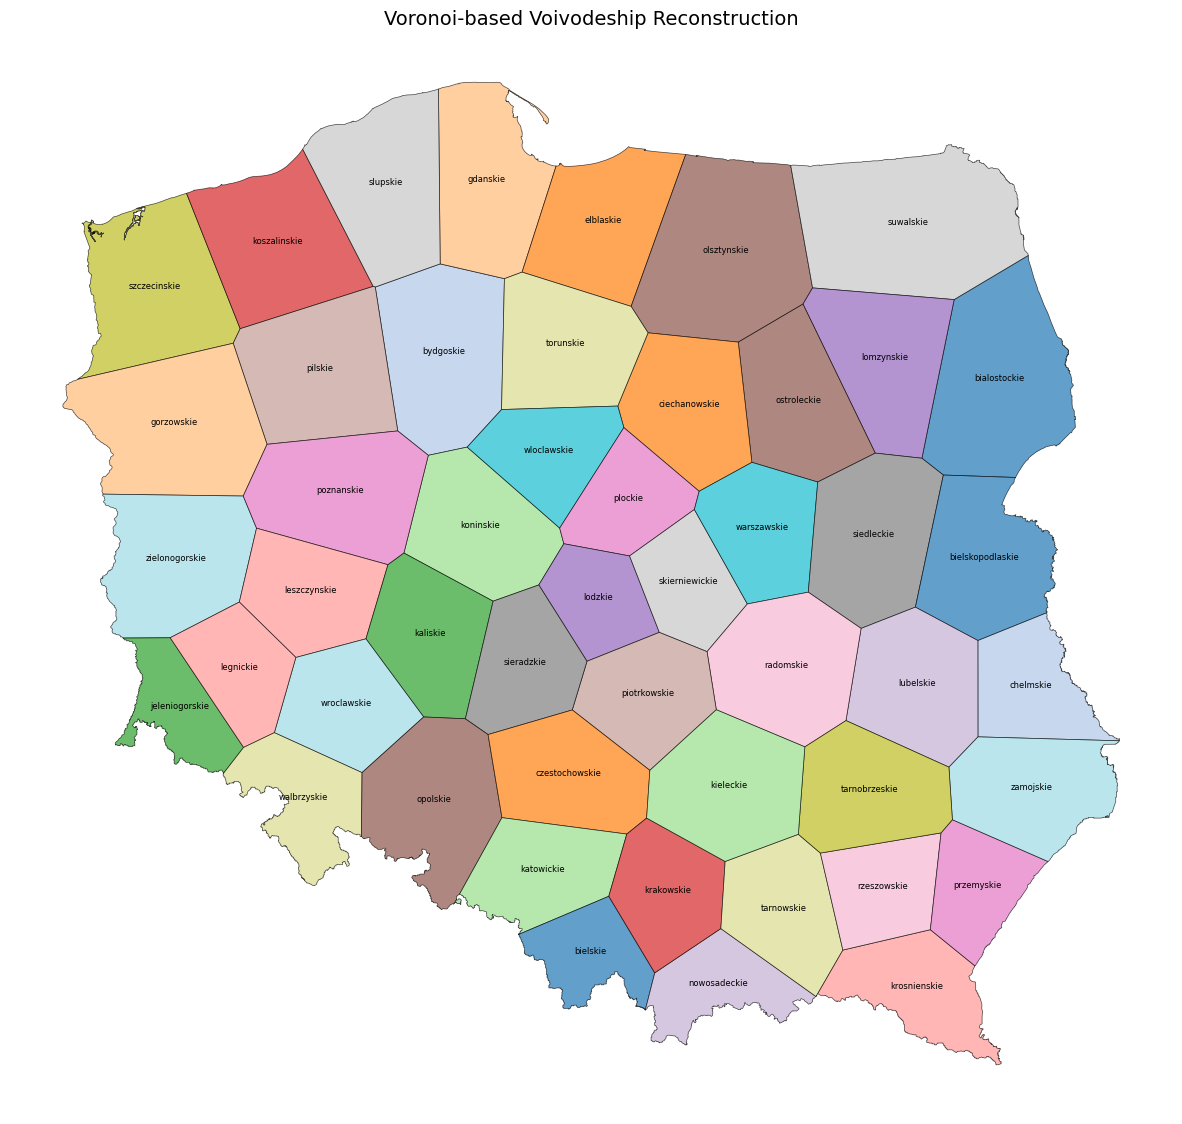

In [20]:
# =============================================================================
# STEP 10: Advanced Method - Use Voronoi-Based Border Reconstruction
# =============================================================================
# Since the SVG has imprecise outer borders and gaps, we use a more robust approach:
# 1. Extract centroids of each voivodeship from SVG
# 2. Use Voronoi tessellation to create clean borders
# 3. Clip to GADM Poland boundary

from scipy.spatial import Voronoi
from shapely.geometry import LineString, box

def create_voronoi_voivodeships(gdf, poland_boundary, buffer_distance=50000):
    """
    Create voivodeship boundaries using Voronoi tessellation from centroids.
    This ensures complete coverage with no gaps or overlaps.
    """
    # Get centroids
    centroids = []
    names = []
    for idx, row in gdf.iterrows():
        centroid = row.geometry.centroid
        centroids.append([centroid.x, centroid.y])
        names.append(row['name'])
    
    centroids = np.array(centroids)
    
    # Add boundary points to handle edge voivodeships properly
    # Get bounding box with buffer
    minx, miny, maxx, maxy = poland_boundary.bounds
    buffer = buffer_distance
    
    # Add virtual points outside the boundary
    boundary_points = [
        [minx - buffer, miny - buffer],
        [minx - buffer, maxy + buffer],
        [maxx + buffer, miny - buffer],
        [maxx + buffer, maxy + buffer],
        [(minx + maxx) / 2, miny - buffer * 2],
        [(minx + maxx) / 2, maxy + buffer * 2],
        [minx - buffer * 2, (miny + maxy) / 2],
        [maxx + buffer * 2, (miny + maxy) / 2],
    ]
    
    all_points = np.vstack([centroids, boundary_points])
    
    # Create Voronoi diagram
    vor = Voronoi(all_points)
    
    # Extract regions for original centroids only
    voronoi_polygons = []
    for i in range(len(centroids)):
        region_idx = vor.point_region[i]
        region = vor.regions[region_idx]
        
        if -1 not in region and len(region) > 0:
            polygon_coords = [vor.vertices[v] for v in region]
            poly = Polygon(polygon_coords)
            # Clip to Poland boundary
            poly = poly.intersection(poland_boundary)
            voronoi_polygons.append(poly)
        else:
            # Handle infinite regions by using a large bounding box
            poly = box(minx - buffer, miny - buffer, maxx + buffer, maxy + buffer)
            poly = poly.intersection(poland_boundary)
            voronoi_polygons.append(poly)
    
    # Create GeoDataFrame
    gdf_voronoi = gpd.GeoDataFrame({
        'name': names,
        'geometry': voronoi_polygons
    }, crs=gdf.crs)
    
    return gdf_voronoi

# Create Voronoi-based voivodeships
gdf_voronoi = create_voronoi_voivodeships(gdf_clipped, poland_proj)

# Calculate areas
gdf_voronoi['area_km2'] = gdf_voronoi.geometry.area / 1e6

print("Voronoi-based Voivodeship Areas:")
print(gdf_voronoi[['name', 'area_km2']].sort_values('area_km2', ascending=False).to_string())

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
gdf_voronoi.plot(ax=ax, edgecolor='black', facecolor='lightgreen', linewidth=0.5, alpha=0.7, column='name', cmap='tab20')
for idx, row in gdf_voronoi.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y), ha='center', fontsize=6)
ax.set_title('Voronoi-based Voivodeship Reconstruction', fontsize=14)
ax.axis('off')
plt.show()

In [21]:
# =============================================================================
# STEP 11: Hybrid Method - Use SVG Borders Where Available, Fill Gaps
# =============================================================================
# This combines the original SVG boundaries with gap-filling to create
# the most accurate reconstruction possible

def create_hybrid_voivodeships(gdf_svg_based, gdf_voronoi, poland_boundary):
    """
    Create hybrid voivodeships:
    - Use original SVG-derived borders for internal boundaries
    - Use Voronoi-based assignment only for gaps
    - Clip everything to GADM Poland boundary
    """
    # Start with the gap-filled SVG voivodeships
    gdf_result = gdf_svg_based.copy()
    
    # Ensure complete coverage by checking against Poland boundary
    result_union = unary_union(gdf_result.geometry)
    remaining_gaps = poland_boundary.difference(result_union)
    
    if not remaining_gaps.is_empty:
        print(f"Filling remaining gaps: {remaining_gaps.area / 1e6:.1f} km²")
        
        # Assign remaining gaps using Voronoi approach
        if remaining_gaps.geom_type == 'MultiPolygon':
            gap_parts = list(remaining_gaps.geoms)
        else:
            gap_parts = [remaining_gaps]
        
        for gap in gap_parts:
            if gap.area < 1000:  # Skip tiny gaps
                continue
            
            # Find which Voronoi region this gap belongs to
            gap_centroid = gap.centroid
            for idx, voronoi_row in gdf_voronoi.iterrows():
                if voronoi_row.geometry.contains(gap_centroid):
                    # Find matching voivodeship in result
                    name = voronoi_row['name']
                    match_idx = gdf_result[gdf_result['name'] == name].index
                    if len(match_idx) > 0:
                        old_geom = gdf_result.loc[match_idx[0], 'geometry']
                        new_geom = unary_union([old_geom, gap])
                        gdf_result.loc[match_idx[0], 'geometry'] = new_geom
                    break
    
    # Final clip to Poland boundary
    for idx in gdf_result.index:
        geom = gdf_result.loc[idx, 'geometry']
        clipped = geom.intersection(poland_boundary)
        if not clipped.is_valid:
            clipped = make_valid(clipped)
        gdf_result.loc[idx, 'geometry'] = clipped
    
    return gdf_result

# Create hybrid voivodeships
gdf_hybrid = create_hybrid_voivodeships(gdf_clipped, gdf_voronoi, poland_proj)
gdf_hybrid['area_km2'] = gdf_hybrid.geometry.area / 1e6

# Verify complete coverage
hybrid_union = unary_union(gdf_hybrid.geometry)
final_gaps = poland_proj.difference(hybrid_union)
print(f"\n✓ Final coverage check:")
print(f"  Total voivodeship area: {gdf_hybrid['area_km2'].sum():,.0f} km²")
print(f"  Remaining gaps: {final_gaps.area / 1e6:.1f} km²")

# Display comparison with historical data
print("\n" + "=" * 70)
print("FINAL Voivodeship Area Comparison:")
print("=" * 70)
for idx, row in gdf_hybrid.sort_values('area_km2', ascending=False).iterrows():
    name = row['name']
    extracted = row['area_km2']
    historical = HISTORICAL_AREAS.get(name, None)
    if historical:
        diff_pct = 100 * (extracted - historical) / historical
        print(f"{name:<20} {extracted:>10,.0f} km² (hist: {historical:>6,}, diff: {diff_pct:>+6.1f}%)")

Filling remaining gaps: 1.6 km²

✓ Final coverage check:
  Total voivodeship area: 312,196 km²
  Remaining gaps: 0.0 km²

FINAL Voivodeship Area Comparison:
olsztynskie              12,378 km² (hist: 12,327, diff:   +0.4%)
bialostockie             12,099 km² (hist: 10,055, diff:  +20.3%)
suwalskie                11,933 km² (hist: 10,490, diff:  +13.8%)
bydgoskie                10,207 km² (hist: 10,349, diff:   -1.4%)
kieleckie                 9,347 km² (hist:  9,211, diff:   +1.5%)
szczecinskie              8,996 km² (hist:  9,982, diff:   -9.9%)
gorzowskie                8,826 km² (hist:  8,484, diff:   +4.0%)
pilskie                   8,714 km² (hist:  8,205, diff:   +6.2%)
koszalinskie              8,551 km² (hist:  8,470, diff:   +1.0%)
siedleckie                8,278 km² (hist:  8,499, diff:   -2.6%)
opolskie                  8,137 km² (hist:  8,535, diff:   -4.7%)
zielonogorskie            7,831 km² (hist:  8,868, diff:  -11.7%)
poznanskie                7,684 km² (hist:  8,151, 

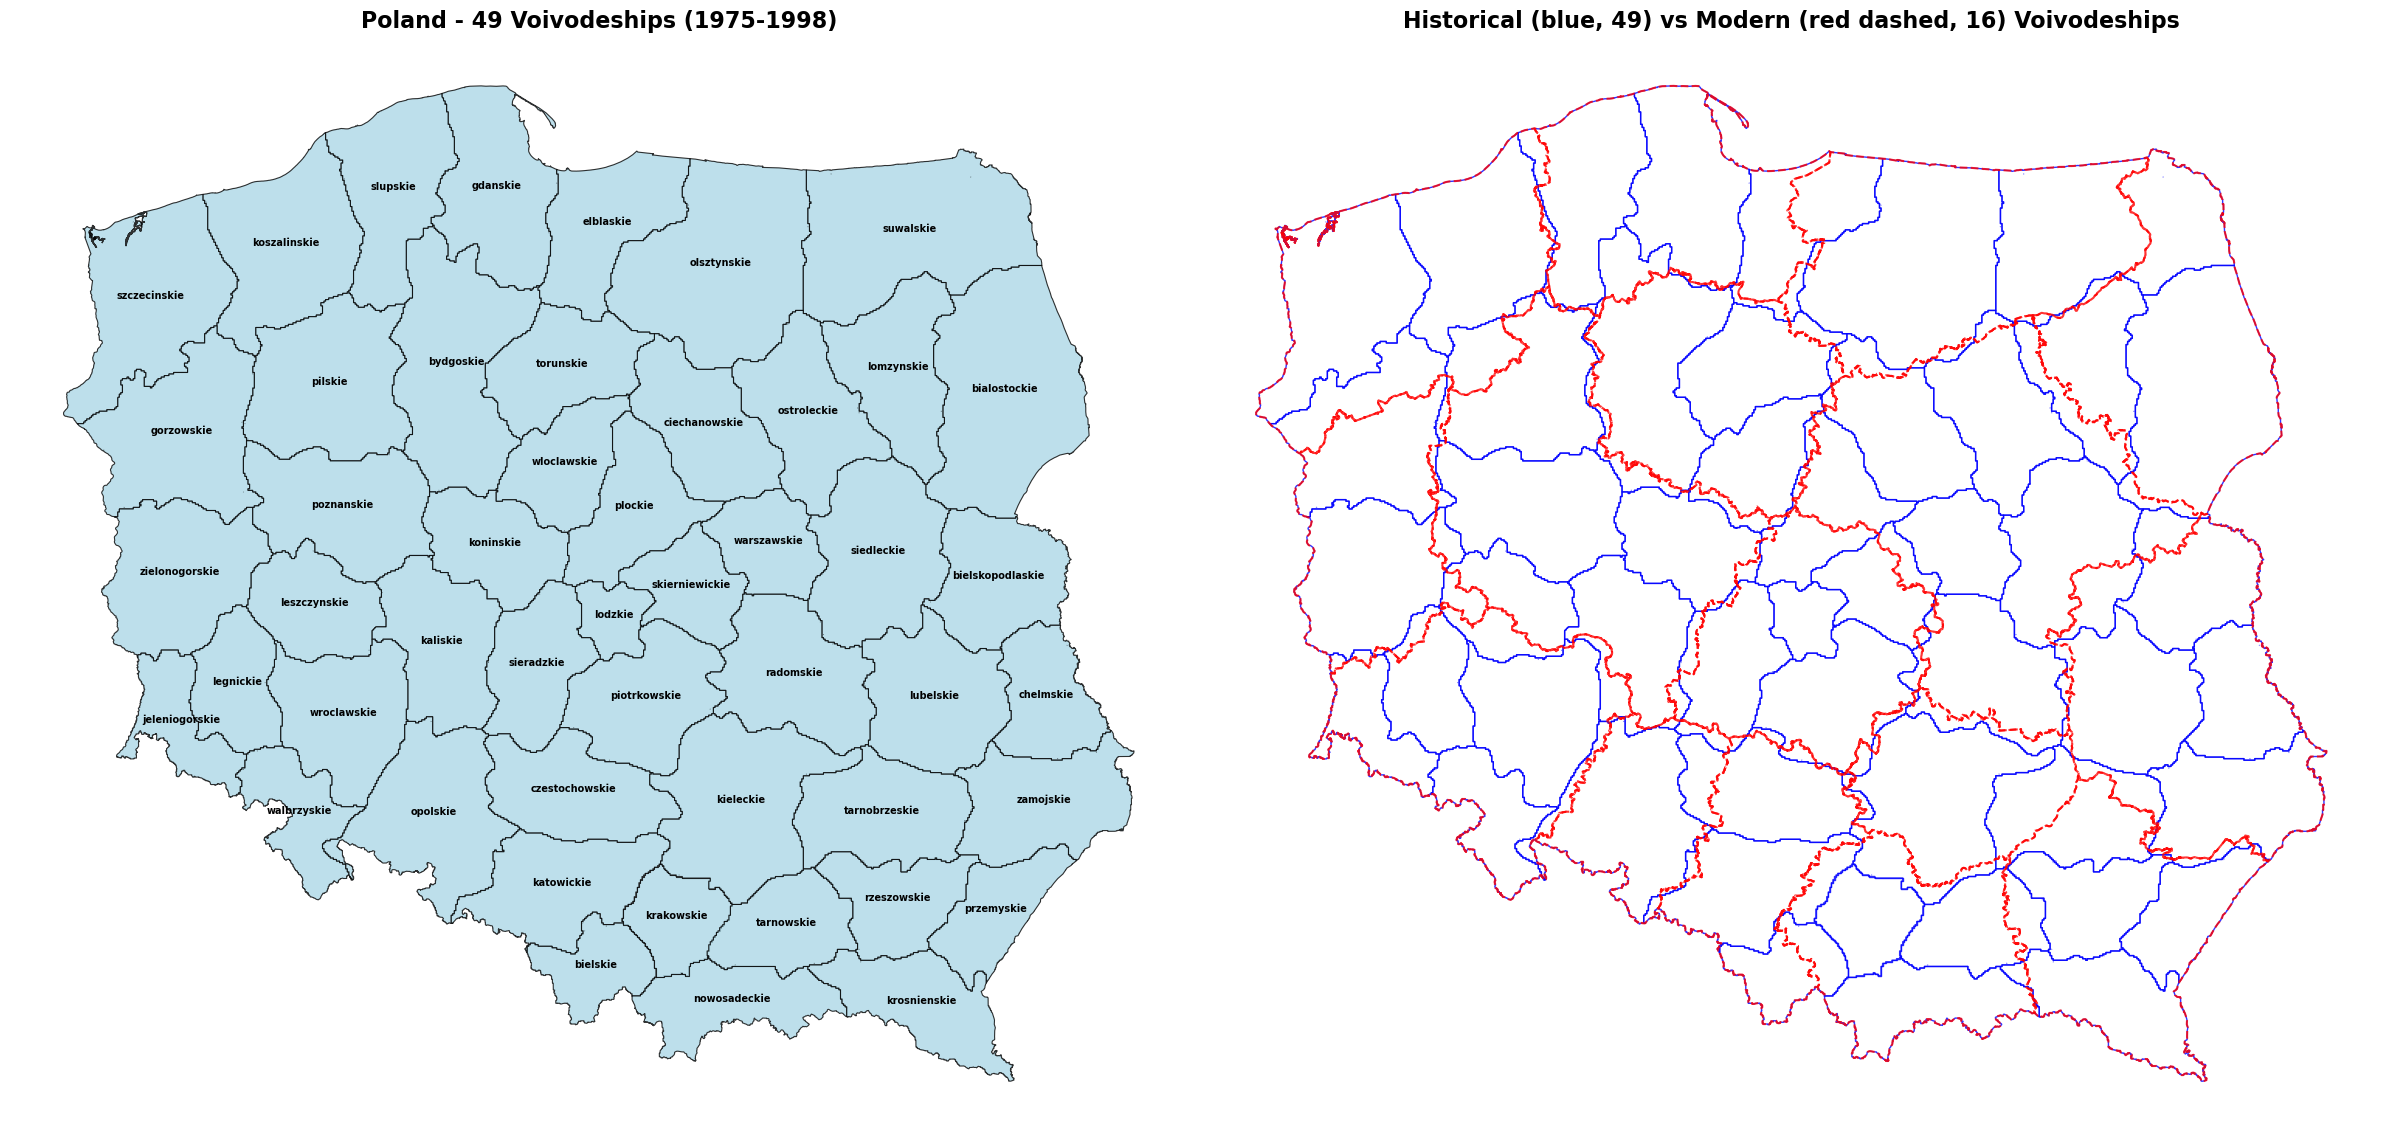


✓ Extracted 49 voivodeships (target: 49)
✓ Total area: 312,196 km²


In [22]:
# =============================================================================
# STEP 12: Final Visualization
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Left: Final voivodeships map
ax1 = axes[0]
gdf_hybrid.plot(ax=ax1, edgecolor='black', facecolor='lightblue', linewidth=0.8, alpha=0.8)
for idx, row in gdf_hybrid.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(row['name'], xy=(centroid.x, centroid.y), ha='center', fontsize=7, fontweight='bold')
ax1.set_title('Poland - 49 Voivodeships (1975-1998)', fontsize=16, fontweight='bold')
ax1.axis('off')

# Right: Comparison with modern voivodeships
ax2 = axes[1]
gdf_hybrid.plot(ax=ax2, edgecolor='blue', facecolor='none', linewidth=1.0, alpha=0.8, label='1975-1998')
# Load modern voivodeships and project
gdf_modern = gpd.read_file(geo_root / "gadm41_POL_shp/gadm41_POL_1.shp").to_crs('EPSG:2180')
gdf_modern.plot(ax=ax2, edgecolor='red', facecolor='none', linewidth=1.5, linestyle='--', alpha=0.8, label='Current (16)')
ax2.set_title('Historical (blue, 49) vs Modern (red dashed, 16) Voivodeships', fontsize=16, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Extracted {len(gdf_hybrid)} voivodeships (target: 49)")
print(f"✓ Total area: {gdf_hybrid['area_km2'].sum():,.0f} km²")

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patches as patches
import svgwrite
import json

def gdf_to_svg_with_metadata(gdf, out_svg='out.svg', width_px=2000, padding_px=10, crs_epsg=2180):
    # 1) project to a planar CRS suitable for drawing
    g = gdf.to_crs(epsg=crs_epsg).copy()

    # 2) compute bounds and scale
    minx, miny, maxx, maxy = g.total_bounds
    w = maxx - minx
    h = maxy - miny
    if w == 0 or h == 0:
        raise ValueError("Zero-size bounds")
    
    # canvas width/height
    W = width_px
    H = int((h / w) * W)
    sx = (W - 2*padding_px) / w
    sy = (H - 2*padding_px) / h
    s = min(sx, sy)

    # Create SVG drawing
    dwg = svgwrite.Drawing(out_svg, size=(f"{W}px", f"{H}px"))
    tx = -minx * s + padding_px
    ty = -miny * s + padding_px

    # Iterate features
    for i, row in g.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        
        # turn properties into JSON for <desc>
        props = row.drop(labels=g.geometry.name).to_dict()
        props_json = json.dumps(props, ensure_ascii=False)

        # Build SVG path(s) for the geometry
        def coords_to_path(coords):
            d = []
            first = True
            for (x, y) in coords:
                scaled_x = (x - minx) * s + padding_px
                scaled_y = H - ((y - miny) * s + padding_px)
                if first:
                    d.append(f"M {scaled_x:.3f} {scaled_y:.3f}")
                    first = False
                else:
                    d.append(f"L {scaled_x:.3f} {scaled_y:.3f}")
            d.append("Z")
            return " ".join(d)

        paths = []
        geom_type = geom.geom_type
        
        if geom_type == "Polygon":
            exterior = coords_to_path(list(geom.exterior.coords))
            holes = [coords_to_path(list(ring.coords)) for ring in geom.interiors]
            paths.append(exterior + " " + " ".join(holes))
        elif geom_type == "MultiPolygon":
            for poly in geom.geoms:
                exterior = coords_to_path(list(poly.exterior.coords))
                holes = [coords_to_path(list(ring.coords)) for ring in poly.interiors]
                paths.append(exterior + " " + " ".join(holes))
        else:
            continue

        # Create path elements
        for pth in paths:
            path_el = dwg.path(d=pth)
            path_el['id'] = f"feat_{i}"
            path_el.update({'fill': 'lightblue', 'stroke': 'black', 'stroke-width': 0.5})
            #path_el.add(dwg.title(str(row.get('name', i))))
            #path_el.add(dwg.desc(props_json))
            dwg.add(path_el)

    dwg.save()
    print("Saved", out_svg)

gdf_to_svg_with_metadata(gdf_hybrid, out_svg="map.svg", width_px=4000)


Saved map.svg


In [23]:
# =============================================================================
# STEP 13: Export Final GeoJSON
# =============================================================================

output_path = geo_root / "voivodeships_1975_final.geojson"

# Prepare for export - convert to WGS84 (EPSG:4326) for GeoJSON standard
gdf_export = gdf_hybrid.copy()
gdf_export = gdf_export.to_crs('EPSG:4326')

# Add metadata
gdf_export['period'] = '1975-1998'
gdf_export['source'] = 'SVG + Voronoi + GADM hybrid reconstruction'
gdf_export['reference'] = 'Wikipedia historical data'

# Keep only relevant columns
export_columns = ['name', 'area_km2', 'reference_km2', 'area_diff_pct', 'period', 'source', 'geometry']
gdf_export = gdf_export[[c for c in export_columns if c in gdf_export.columns]]

# Export
gdf_export.to_file(output_path, driver='GeoJSON')

print(f"✓ Exported to: {output_path}")
print(f"  - Records: {len(gdf_export)}")
print(f"  - CRS: {gdf_export.crs}")
print(f"  - Columns: {list(gdf_export.columns)}")

✓ Exported to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/voivodeships_1975_final.geojson
  - Records: 49
  - CRS: EPSG:4326
  - Columns: ['name', 'area_km2', 'period', 'source', 'geometry']
